# PsyTrack Implementation

This notebook applies PsyTrack to the clean dataset (Roy et al., 2021).

**Paper** : https://pillowlab.princeton.edu/pubs/Roy18_NeurIPS_dynamicPsychophys.pdf     
**GitHub** : https://github.com/nicholas-roy/psytrack

PsyTrack estimates time-varying logistic regression weights on trial-level predictors via a Gaussian random-walk prior and empirical Bayes on smoothness. Tracking weights on SC, OC, prevChoice, and bias over trials complements the preregistered hypothesis tests (H1–H4) by characterising how associations evolve across task contexts with more nuance than the former could. The weights quantify marginal sensitivity to each predictor at each trial, conditional on the full trial sequence. No specific learning mechanism is assumed, leaving the analysis' assumptions flexible.

The dataset has 80 press-enabled trials per subject per task, 160 overall. This is short relative to the training datasets PsyTrack was designed for (thousands of trials as seen in example notebook and linked datasets for the paper) - some subjects' fits are unstable, and flagged below, whilst others show inflated weight magnitudes. I tested different hyperparameter constraints (tighter bounds on sigma), but the instability was structural to the trial count rather than fit-specific. I took the count in consideration in calibrating the interpretations below. 

In [13]:
from pathlib import Path
import psytrack as psy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings

warnings.filterwarnings("ignore")

DATA_PATH = Path("../data/processed/clean_data.csv")
FIGURES_PATH = Path("../figures")
FIGURES_PATH.mkdir(exist_ok=True)
PROPERTIES = ["colour", "size", "velocity"]

WEIGHT_COLORS = {"bias": "#555555", "SC": "#E41A1C", "OC": "#377EB8", "prevChoice": "#4DAF4A"}
WEIGHT_ZORDER = {"bias": 1, "prevChoice": 2, "OC": 4, "SC": 5}

df = pd.read_csv(DATA_PATH)
active = (
    df.loc[(df["phase"] == "outcome") & (df["watch_only"] == 0)]
    .sort_values(["subject_id", "task", "block", "trial_n"])
    .reset_index(drop=True)
)

test_subjects = active["subject_id"].drop_duplicates().sample(3, random_state=42).tolist()

print(f"Press-enabled trials: {len(active):,}")
print(f"Subjects: {active['subject_id'].nunique()}")

Press-enabled trials: 11,200
Subjects: 70


## Model Specification (*design + input matrix*)

PsyTrack takes `y`and `input`arguments, which respectively indicate the subject's trial choice and relevant variables. I drew on the paper's 'Method Details' (*Selection of input variables*), and decided to use the input variables indicated below. Though approximate log-evidence could have been used to identify relevant variables, the pre-registration and overall goal of the experiment remain to determine whether SC-related learning transfers across tasks, and whether notable differences in OC and SC learning occur. These were kept in focus for input selection - the experiment is sufficiently simple for a small set of weights to satisfactorily answer the question.

**Inputs**
- SC and OC are binary indicators of whether the task-specific active property value is present on each trial. 
    - SC-active values are task-specific : colour-SC subjects see blue in Task 1 and green in Task 2, because colour values differ between tasks by design.
    - OC-active values are inferred from the actual `trial_role == 'OC'` rows within each subject-task. This is deliberate: in `clean_data.csv`, `prop_OC`/`prop_R` are corrected analysis labels used for behavioural transfer checks, but the PsyTrack design matrix needs the trial-level high-outcome OC predictor. In Task 2, this role-derived OC predictor aligns with `prop_R`, not `prop_OC`, after the metadata swap.
- R was excluded from the model, as it has no single active value : the outcome probability under R (p = 0.10) is not conditional on a particular stimulus being present. 
- The residual press tendency is absorbed by the bias term. 
- prevChoice captures autocorrelation in choice (positive = perseveration, negative = alternation), as recommended in the paper.    

All the inputs were parametrised as (0, 1).

**y**
- Took the `pressed`column from the clean dataset (0, 1), and incremented +1 to fit with PsyTrack's parametrisation (1, 2).

**Length**  
I used `dayLength` to specify transitions where behaviour was expected to shift. In the experiment, there were 2 levels of change : block-specific within each task, and at the boundaries of the tasks themselves. 
- Of the 3 blocks in each task, only blocks 2 and 3 were considered (1 being watch-only, and therefore not producing any 'choice' signal). Block 2 involves 60 trials in which SC, OC, and R function as specified (p = 0.95, 0.90, 0.10 respectively), and press outcomes are shown (reversal, or not). Block 3 does not show outcomes, and involves fewer trials, at 20 overall.
- The transition between Task 1 and Task 2 is one of the central objects of the experiment's focus : whether SC-learning transfers over. At this boundary, SC and OC swap. To observe the effects of this transition, I needed to consider Task 1 and 2 both separately and as a unit. `dayLength` is defined as [60,20] for task-specific models, and [60,20,60,20] for the 'whole-experiment' model.


In [14]:
def infer_task_property_specs(df_task):
    """Infer role-based SC and OC inputs for one subject-task.

    PsyTrack needs indicators for the trial-level predictors of behaviour. For OC,
    that means the property value defining rows with trial_role == 'OC'. In Task 2,
    this deliberately does not use prop_OC directly: after the behavioural metadata
    correction, the role-based OC predictor aligns with prop_R.
    """
    roles = {r: df_task.loc[df_task["trial_role"] == r] for r in ["SC", "OC", "R"]}
    subject_id = df_task["subject_id"].iloc[0]
    task = int(df_task["task"].iloc[0])

    sc_prop = df_task["prop_SC"].iloc[0]
    sc_vals = roles["SC"][f"trial_{sc_prop}"].dropna().unique().tolist()
    if len(sc_vals) != 1:
        raise ValueError(f"{subject_id} task {task}: SC not unique on SC trials ({sc_prop}): {sc_vals}")

    oc_candidates = []
    for prop in [p for p in PROPERTIES if p != sc_prop]:
        oc_v = roles["OC"][f"trial_{prop}"].dropna().unique().tolist()
        r_v = roles["R"][f"trial_{prop}"].dropna().unique().tolist()
        if len(oc_v) == 1 and len(r_v) == 1 and oc_v[0] != r_v[0]:
            oc_candidates.append((prop, oc_v[0]))

    if len(oc_candidates) != 1:
        raise ValueError(f"{subject_id} task {task}: expected one role-based OC candidate, got {oc_candidates}")

    oc_prop, oc_active = oc_candidates[0]
    return {
        "subject_id": subject_id,
        "task": task,
        "sc_prop": sc_prop,
        "sc_active": sc_vals[0],
        "oc_prop": oc_prop,
        "oc_active": oc_active,
        "metadata_prop_OC": df_task["prop_OC"].iloc[0],
        "metadata_prop_R": df_task["prop_R"].iloc[0],
    }


def validate_role_based_specs(active_df):
    """Check how role-derived OC inputs relate to corrected metadata labels."""
    rows = []
    for _, df_task in active_df.groupby(["subject_id", "task"]):
        specs = infer_task_property_specs(df_task)
        rows.append({
            "subject_id": specs["subject_id"],
            "task": specs["task"],
            "role_oc_prop": specs["oc_prop"],
            "metadata_prop_OC": specs["metadata_prop_OC"],
            "metadata_prop_R": specs["metadata_prop_R"],
            "matches_prop_OC": specs["oc_prop"] == specs["metadata_prop_OC"],
            "matches_prop_R": specs["oc_prop"] == specs["metadata_prop_R"],
        })
    validation = pd.DataFrame(rows)
    print("Role-derived OC predictor vs corrected metadata labels:")
    print(pd.crosstab(validation["task"], validation["matches_prop_OC"], rownames=["task"], colnames=["matches prop_OC"]))
    print(pd.crosstab(validation["task"], validation["matches_prop_R"], rownames=["task"], colnames=["matches prop_R"]))
    return validation


spec_validation = validate_role_based_specs(active)


def build_task_dataset(df_task):
    """PsyTrack dataset for one subject (one task)."""
    df_task = df_task.sort_values(["block", "trial_n"]).reset_index(drop=True).copy()
    specs = infer_task_property_specs(df_task)
    dataset = {
        "name": f"{specs['subject_id']}_task{specs['task']}",
        "y": df_task["pressed"].astype(int).to_numpy() + 1,
        "inputs": {
            "SC": (df_task[f"trial_{specs['sc_prop']}"] == specs["sc_active"]).astype(float).to_numpy()[:, None],
            "OC": (df_task[f"trial_{specs['oc_prop']}"] == specs["oc_active"]).astype(float).to_numpy()[:, None],
            "prevChoice": df_task["pressed"].shift(1, fill_value=0).astype(float).to_numpy()[:, None],
        },
        "dayLength": np.array([60, 20]),
    }
    return dataset, specs


def build_subject_dataset(subject_df):
    """PsyTrack dataset for one subject (both tasks are concatenated)."""
    subject_id = subject_df["subject_id"].iloc[0]
    parts = {"SC": [], "OC": [], "prevChoice": [], "y": []}

    for task in [1, 2]:
        df_t = (
            subject_df[subject_df["task"] == task]
            .sort_values(["block", "trial_n"])
            .reset_index(drop=True)
        )
        if len(df_t) != 80:
            raise ValueError(f"{subject_id} task {task}: expected 80 trials, got {len(df_t)}")
        specs = infer_task_property_specs(df_t)
        parts["SC"].append((df_t[f"trial_{specs['sc_prop']}"] == specs["sc_active"]).astype(float).values)
        parts["OC"].append((df_t[f"trial_{specs['oc_prop']}"] == specs["oc_active"]).astype(float).values)
        parts["prevChoice"].append(df_t["pressed"].shift(1, fill_value=0).astype(float).values)
        parts["y"].append(df_t["pressed"].values)

    pc = np.concatenate(parts["prevChoice"])
    pc[80] = 0.0  # reset at task transition
    y = np.concatenate(parts["y"]).astype(int)
    assert len(y) == 160

    return {
        "name": subject_id,
        "y": y + 1,
        "inputs": {
            "SC": np.concatenate(parts["SC"])[:, None],
            "OC": np.concatenate(parts["OC"])[:, None],
            "prevChoice": pc[:, None],
        },
        "dayLength": np.array([60, 20, 60, 20]),
    }


def fit_psytrack(D, use_sigday=True):
    """Fit PsyTrack on D; optimise sigma (and sigDay when use_sigday=True)."""
    weights = {"bias": 1, "SC": 1, "OC": 1, "prevChoice": 1}
    K = sum(weights.values())
    hyper = {
        "sigInit": 2 ** 4,
        "sigma": [2 ** -4] * K,
        "sigDay": [2 ** -4] * K if use_sigday else None,
    }
    optList = ["sigma", "sigDay"] if use_sigday else ["sigma"]
    hyp, evd, wMode, hess_info = psy.hyperOpt(D, hyper, weights, optList)
    return weights, hyp, evd, wMode, hess_info


def weight_names(weights):
    return sorted(weights.keys())


Role-derived OC predictor vs corrected metadata labels:
matches prop_OC  False  True 
task                         
1                    0     70
2                   70      0
matches prop_R  False  True 
task                        
1                  70      0
2                   0     70


## Fit configuration

- `sigInit` = 2^4 follows the example notebook's recommendation: starting weights large enough to be determined primarily by the data likelihood rather than the prior. 
- `sigma` (trial-to-trial smoothness) and `sigDay` (permitted weight jump at session boundaries) are both optimised via empirical Bayes.       

The session boundaries are declared at the block 2 to block 3 transition within each task, and additionally at the task boundary in the concatenated fit (rationale in markdown cell above). Per-task fits (tested and shown below for three subjects) are for illustration and to test individual fit, since the concatenated tasks view remains the primary analysis.

The interpretations are written in the Markdown cells below.

In [15]:
task_fits = {}

for subject_id in test_subjects:
    for task in [1, 2]:
        df_task = active.loc[(active["subject_id"] == subject_id) & (active["task"] == task)]
        D, specs = build_task_dataset(df_task)
        weights, hyp, evd, wMode, hess_info = fit_psytrack(D, use_sigday=True)
        task_fits[(subject_id, task)] = {
            "D": D, "specs": specs, "weights": weights,
            "hyp": hyp, "evd": evd, "wMode": wMode, "hess_info": hess_info,
        }

print("Per-task fits (3 illustrative subjects):")
for (sid, task), fit in task_fits.items():
    print(f"  {sid[:16]} T{task}: log evidence = {fit['evd']:.1f}")

Per-task fits (3 illustrative subjects):
  62b2080f8f89f2f1 T1: log evidence = -63.5
  62b2080f8f89f2f1 T2: log evidence = -58.8
  542bdb6dfdf99b32 T1: log evidence = -17.4
  542bdb6dfdf99b32 T2: log evidence = -18.2
  67792abbab2fa21b T1: log evidence = -65.8
  67792abbab2fa21b T2: log evidence = -65.0


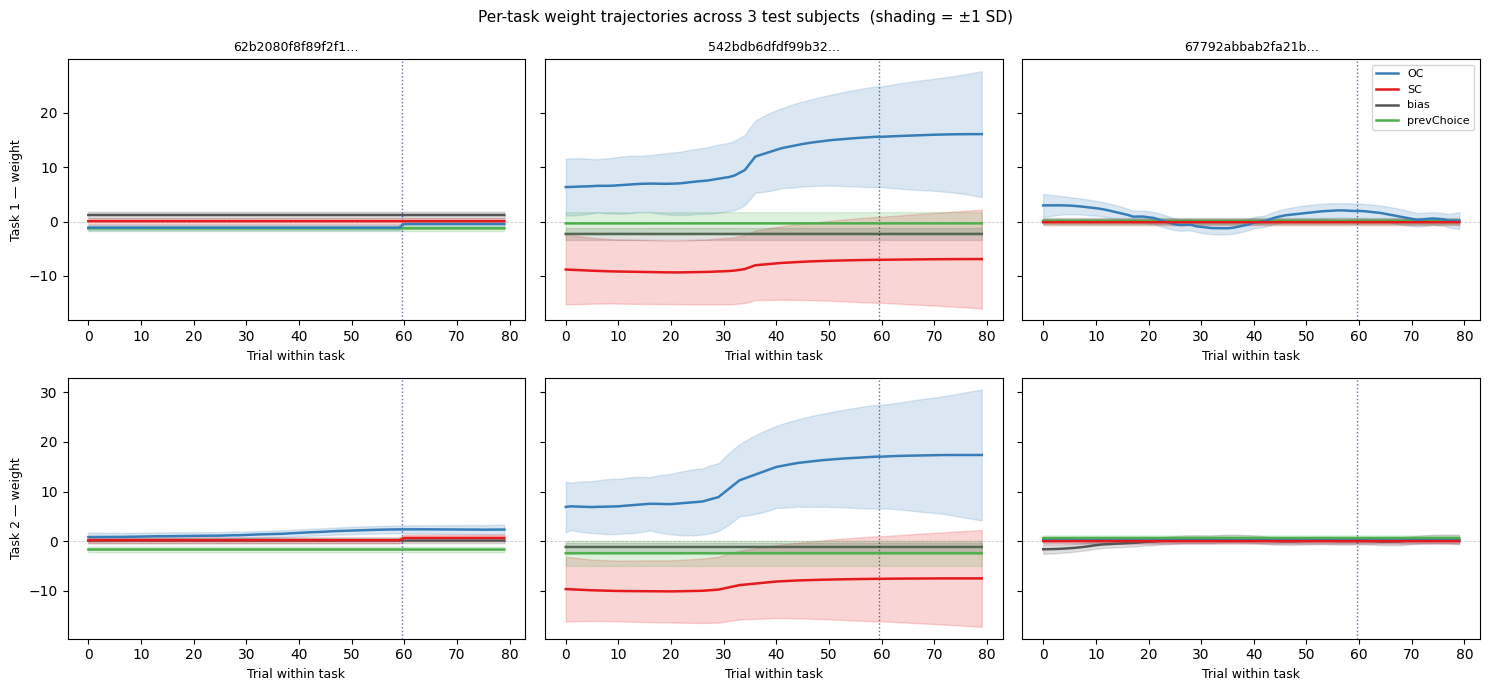

In [16]:
fig, axes = plt.subplots(2, len(test_subjects), figsize=(5 * len(test_subjects), 7), sharey="row")

for row, task in enumerate([1, 2]):
    for col, subject_id in enumerate(test_subjects):
        ax = axes[row, col]
        fit = task_fits[(subject_id, task)]
        wns = weight_names(fit["weights"])
        t = np.arange(fit["wMode"].shape[1])
        boundary = int(fit["D"]["dayLength"][0])

        ax.axhline(0, color="grey", lw=0.6, ls="--", alpha=0.4)
        ax.axvline(boundary - 0.5, color="navy", lw=1.0, ls=":", alpha=0.6)
        for idx, name in enumerate(wns):
            w = fit["wMode"][idx]
            s = fit["hess_info"]["W_std"][idx]
            c = WEIGHT_COLORS.get(name, "#888888")
            ax.fill_between(t, w - s, w + s, color=c, alpha=0.18)
            ax.plot(t, w, color=c, lw=1.8, label=name, zorder=WEIGHT_ZORDER.get(name, 3))

        ax.set_xlabel("Trial within task", fontsize=9)
        if col == 0:
            ax.set_ylabel(f"Task {task} \u2014 weight", fontsize=9)
        if row == 0:
            ax.set_title(subject_id[:16] + "\u2026", fontsize=9)
        if row == 0 and col == len(test_subjects) - 1:
            ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    "Per-task weight trajectories across 3 test subjects  (shading = \u00b11 SD)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "per_task_weight_trajectories.png", dpi=150)
plt.show()

The random selection of 3 subjects was varied several times to test whether meaningful differences in weight trajectories could be observed. In several tests, weights resembled the above : near 0 across `SC`, `bias`, and `prevChoice`, with variations in `OC` and very large CI.

Despite these swings, the three test subjects were kept - they represent the range of fit quality in the dataset well. There is much variation from subject-to-subject, and the signal - SC learning - is small. Likely too small to be reliably picked up within 80 trials.

- Subject 62b2080f shows moderate discrimination with weights in a small but plausible range.
- Subject 542bdb6d shows tight alginment between empirical and model press rates, but achieves this with weight magnitudes above +/-8 in logit space, which is well beyond the flagged range. This illustrates a specific failure mode that was observed repeatedly in the test subject sets: the model fits behavioural patterns accurately, but by inflating weights to near-deterministic values rather than through meaningful trajectories. This subject appears in the flagged list (next section below). 
- Subject 67792 shows no clear learning signal across either task — weight trajectories stay near zero and the model does not improve on a constant press rate, suggesting behaviour that is not contingency-sensitive in this session. 

Weights are in logit space, so a weight of +1 on OC corresponds to an increase in press probability from 50% (at bias only) to approximately 73% when OC-positive is present. Weights above ~3 imply near-deterministic pressing and are an indicator of overfitting on short sequences. Given the small trial count relative to PsyTrack's typical range, this is unsurprising.

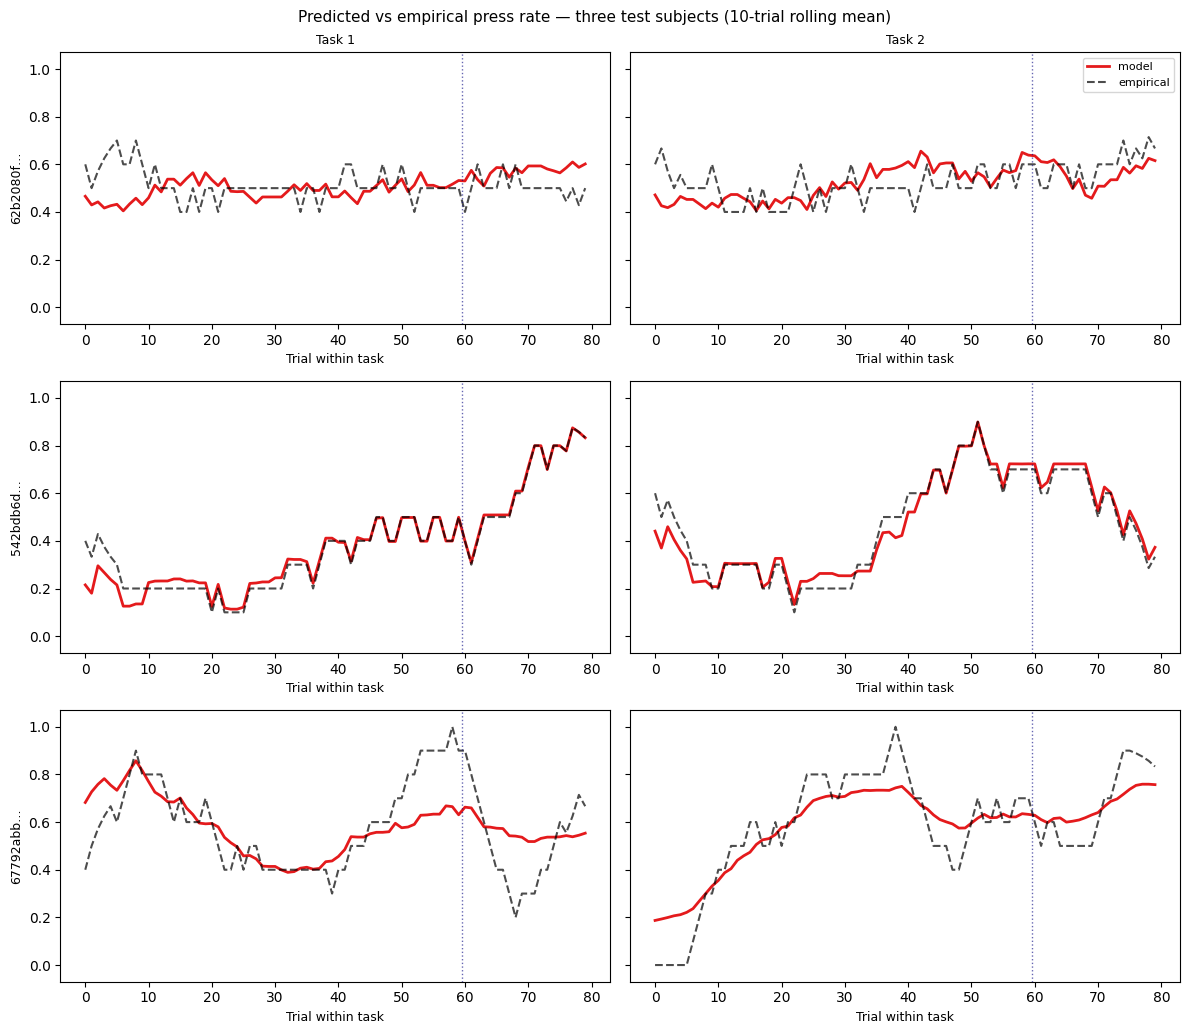

In [17]:
fig, axes = plt.subplots(len(test_subjects), 2, figsize=(12, 3.5 * len(test_subjects)), sharey=True)

for row, subject_id in enumerate(test_subjects):
    for col, task in enumerate([1, 2]):
        ax = axes[row, col]
        fit = task_fits[(subject_id, task)]
        D, wMode = fit["D"], fit["wMode"]
        wns = weight_names(fit["weights"])
        T = wMode.shape[1]

        X = np.zeros((T, len(wns)))
        for i, name in enumerate(wns):
            X[:, i] = 1.0 if name == "bias" else D["inputs"][name][:, 0]
        p_pred = 1.0 / (1.0 + np.exp(-(X * wMode.T).sum(axis=1)))

        y = (D["y"] - 1).astype(float)
        t = np.arange(T)
        roll_pred = pd.Series(p_pred).rolling(10, min_periods=1, center=True).mean().values
        roll_emp  = pd.Series(y).rolling(10, min_periods=1, center=True).mean().values

        ax.plot(t, roll_pred, color=WEIGHT_COLORS["SC"], lw=2.0, label="model")
        ax.plot(t, roll_emp,  color="black", lw=1.5, ls="--", alpha=0.7, label="empirical")
        ax.axvline(59.5, color="navy", lw=1.0, ls=":", alpha=0.6)
        ax.set_ylim(-0.07, 1.07)
        ax.set_xlabel("Trial within task", fontsize=9)
        if col == 0:
            ax.set_ylabel(subject_id[:8] + "…", fontsize=9)
        if row == 0:
            ax.set_title(f"Task {task}", fontsize=9)
        if row == 0 and col == 1:
            ax.legend(fontsize=8, loc="upper right")

fig.suptitle(
    "Predicted vs empirical press rate — three test subjects (10-trial rolling mean)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "psytrack_behavioural_validation.png", dpi=150)
plt.show()

The same variability between subjects applies to predicted vs. empirical press rates. Alignment between the two measures indicates that the model is tracking behaviourally relevant signal rather than fitting noise, though the issue remains that predictive performance fluctuates : 
- Subject 542bdb6d shows tight alignment (log evidence -17.42 and -18.2). 
- Subject 67792, on the other hand, shows poor alignment in both tasks. The results are consistent with near-zero weight trajectories and behaviour that is not contingency-sensitive (log evidence -65.8, -65.0)
- Subject 62b2080f shows moderate correspondence, with some divergence in Block 3 where outcome feedback is absent (log evidence -63.5, -58.8)

## Transfer Learning - weight trajectories across tasks

To test whether property-indexed learning transfered between tasks, T1 and T2 were concatenated into a single 160-trial PsyTrack dataset per subject. The task boundary was declared as a session break via `sigDay` (see Model Specification above).         
- If subjects track contingency by role (the SC property reliably predicts outcome across both tasks), the SC weight should persist across trial 80.          
- If subjects instead track the physical stimulus, the SC weight should reset at the task transition.       

Fitted `sigDay` values quantify this directly, with small `sigDay` implying the model finds continuity, and large sigDay implying more of a structural break (and therefore, no transfer).

The four session segments are T1-B2 (trials 0–59), T1-B3 (60–79), T2-B2 (80–139), T2-B3 (140–159). `dayLength` = [60, 20, 60, 20]. 
   
To filter for overfitting, I excluded subjects whose weigths were > 5 : this resulted in 21 of 68 successfully fit subjects being flagged. 47 subjects remained, whose model evidence was then evaluated against a constant press rate to check validity. Interpretation is written below.

In [18]:
FITS_PATH = Path("../data/processed/psytrack_fits_v2.pkl")

if FITS_PATH.exists():
    with open(FITS_PATH, "rb") as fh:
        v2_fits = pickle.load(fh)
    print(f"Loaded {len(v2_fits)} fits from {FITS_PATH}")
else:
    v2_fits, v2_failed = {}, []
    for subject_id in active["subject_id"].unique():
        try:
            D = build_subject_dataset(active[active["subject_id"] == subject_id])
            weights, hyp, evd, wMode, hess_info = fit_psytrack(D, use_sigday=True)
            v2_fits[subject_id] = {
                "D": D, "weights": weights, "hyp": hyp,
                "evd": evd, "wMode": wMode, "hess_info": hess_info,
            }
        except Exception as e:
            v2_failed.append({"subject_id": subject_id, "error": str(e)})
            print(f"FAILED {subject_id[:16]}: {e}")
    with open(FITS_PATH, "wb") as fh:
        pickle.dump(v2_fits, fh)
    print(f"Fitted {len(v2_fits)} subjects. Failures: {len(v2_failed)}")
    if v2_failed:
        for f in v2_failed:
            print(f"  {f['subject_id']}: {f['error']}")

Loaded 68 fits from ../data/processed/psytrack_fits_v2.pkl


In [24]:
HYPER_PATH = Path("../data/processed/psytrack_hyperparameter_summary.csv")

if HYPER_PATH.exists():
    hyper_df = pd.read_csv(HYPER_PATH)
else:
    rows = []
    for subject_id, fit in v2_fits.items():
        wns = weight_names(fit["weights"])
        hyp, wMode = fit["hyp"], fit["wMode"]
        row = {
            "subject_id": subject_id,
            "log_evidence": float(fit["evd"]),
            "max_abs_weight": float(np.abs(wMode).max()),
        }
        for k, name in enumerate(wns):
            row[f"sigma_{name}"]  = float(hyp["sigma"][k])
            row[f"sigDay_{name}"] = float(hyp["sigDay"][k])
        rows.append(row)
    col_order = [
        "subject_id",
        "sigma_SC", "sigma_OC", "sigma_prevChoice", "sigma_bias",
        "sigDay_SC", "sigDay_OC", "sigDay_prevChoice", "sigDay_bias",
        "log_evidence", "max_abs_weight",
    ]
    hyper_df = pd.DataFrame(rows)[col_order]
    hyper_df.to_csv(HYPER_PATH, index=False)

flagged_ids = set(hyper_df.loc[hyper_df["max_abs_weight"] > 5, "subject_id"])
good_df = hyper_df[~hyper_df["subject_id"].isin(flagged_ids)]

print(f"Flagged (max_abs_weight > 5): {len(flagged_ids)} of {len(hyper_df)} subjects")
print(f"\nMean \u00b1 SE of fitted sigDay ({len(good_df)} non-flagged subjects):")
for name in ["SC", "OC", "prevChoice", "bias"]:
    col = f"sigDay_{name}"
    m, se = good_df[col].mean(), good_df[col].std() / np.sqrt(len(good_df))
    print(f"sigDay_{name:12s}: {m:.5f} \u00b1 {se:.5f}")

hyper_df.head(10)

Flagged (max_abs_weight > 5): 21 of 68 subjects

Mean ± SE of fitted sigDay (47 non-flagged subjects):
sigDay_SC          : 0.38975 ± 0.13315
sigDay_OC          : 0.56146 ± 0.13983
sigDay_prevChoice  : 0.24607 ± 0.07526
sigDay_bias        : 0.48989 ± 0.13692


,subject_id,sigma_SC,sigma_OC,sigma_prevChoice,sigma_bias,sigDay_SC,sigDay_OC,sigDay_prevChoice,sigDay_bias,log_evidence,max_abs_weight
0,542bdb6dfdf99b324ea37c3a,0.092357,2.216538,0.008014,0.002689,0.082164,0.068230,0.033816,0.027679,-32.677959,18.709923
1,56eeb66a524cc0000a5fa4a2,3.858973,0.003374,0.014342,1.169631,0.055575,3.104042,11.561441,0.036899,-44.870365,10.046496
2,5827634ea80bf4000199994b,0.196555,0.000075,0.369442,0.062748,4.333626,0.106402,0.230538,0.289441,-94.236373,7.563017
3,598f22af33481c000164d359,0.473407,0.004612,0.008286,0.566374,0.024945,0.021403,2.030019,0.033079,-60.873487,3.543549
4,5996d2256b939900012d9f22,0.000442,0.005026,0.000379,0.101629,0.122889,0.069441,0.047496,1.152561,-122.636272,1.180279
5,5a6725d4c0d836000107f6e7,0.002563,0.018145,0.608019,0.001564,0.021582,7.445112,4.628601,0.007387,-74.391022,8.032491
6,5abbe13268b65b00018cf94b,0.003671,0.004732,0.005159,0.145336,0.022674,2.116478,0.040913,0.027165,-98.176598,3.195266
7,5ad0422dfb109b0001a30f35,0.004655,1.503866,0.005883,0.234677,0.016809,0.053662,0.023545,3.053370,-77.025229,7.333133
8,5b9d57e5737d030001ad2cbf,0.085905,0.002910,0.005689,0.007264,0.044496,0.713667,0.031538,0.669628,-108.092208,1.652975
9,5baa3265c0a8c000014bea73,0.205215,0.138765,0.116941,0.367002,0.016885,0.111984,0.035965,0.010809,-76.452190,4.788739


PsyTrack > null: 16 of 47 non-flagged subjects


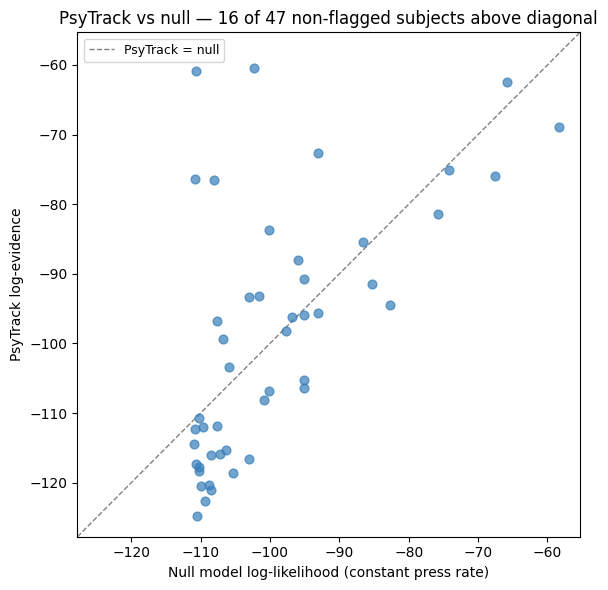

In [20]:
null_rows = []
for subject_id, fit in v2_fits.items():
    y = (fit["D"]["y"] - 1).astype(float)
    p_null = float(y.mean())
    null_ll = float(np.sum(
        y * np.log(p_null + 1e-12) + (1 - y) * np.log(1 - p_null + 1e-12)
    ))
    null_rows.append({"subject_id": subject_id, "psytrack_evd": fit["evd"], "null_ll": null_ll})

evd_df = pd.DataFrame(null_rows)
good_evd = evd_df[~evd_df["subject_id"].isin(flagged_ids)]
n_above = int((good_evd["psytrack_evd"] > good_evd["null_ll"]).sum())

print(f"PsyTrack > null: {n_above} of {len(good_evd)} non-flagged subjects")

lo = min(good_evd["null_ll"].min(), good_evd["psytrack_evd"].min()) - 3
hi = max(good_evd["null_ll"].max(), good_evd["psytrack_evd"].max()) + 3

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(good_evd["null_ll"], good_evd["psytrack_evd"],
           color=WEIGHT_COLORS["OC"], alpha=0.7, s=40, zorder=3)
ax.plot([lo, hi], [lo, hi], color="grey", lw=1.0, ls="--", zorder=1, label="PsyTrack = null")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Null model log-likelihood (constant press rate)")
ax.set_ylabel("PsyTrack log-evidence")
ax.set_title(
    f"PsyTrack vs null — {n_above} of {len(good_evd)} non-flagged subjects above diagonal"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "psytrack_vs_null_evidence.png", dpi=150)
plt.show()

Points above the diagonal are subjects for whom PsyTrack's time-varying weights provide better log-evidence than a constant press rate. For subjects below the diagonal, the model's additional flexibility does not improve on the null, consistent with near-zero weight trajectories and low within-session discrimination — the same subjects who tend to appear in the flagged group or on the boundary of it.

The final number - only 16 / 47 non-flagged subjects - points to the conclusion that weight trajectories provide little predictive power in this instance. Whether this reflects a weak SC signal, insufficient trials per subject, or both is unclear from the current data.

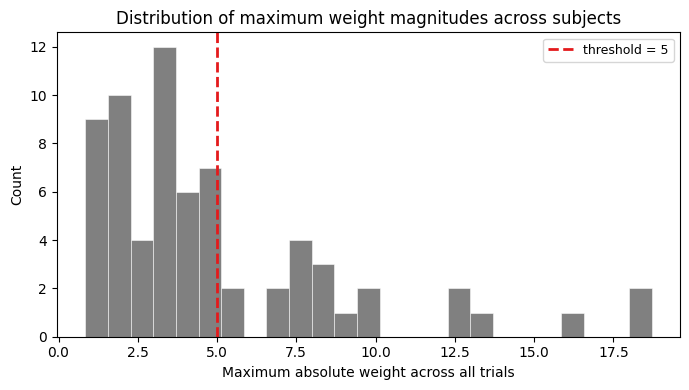

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(hyper_df["max_abs_weight"], bins=25, color="#555555", alpha=0.75,
        edgecolor="white", linewidth=0.5)
ax.axvline(5, color=WEIGHT_COLORS["SC"], lw=2.0, ls="--", label="threshold = 5")
ax.set_xlabel("Maximum absolute weight across all trials")
ax.set_ylabel("Count")
ax.set_title("Distribution of maximum weight magnitudes across subjects")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "psytrack_fit_quality_diagnostic.png", dpi=150)
plt.show()

Subjects to the right of the dashed threshold line were flagged and excluded from aggregate analysis. The distribution is right-skewed, with most subjects concentrated below 5 and a dispersed tail reaching above 15 — the tail corresponds to fits where the optimiser found a high-likelihood solution by allowing one or more weights to grow without bound over a short sequence.

## Fit quality

21 of 68 successfully fit subjects (31%) have maximum weight magnitude above 5, indicating unstable optimisation. This likely reflects the short per-subject trial count (160 trials) relative to the model’s flexibility: four time-varying weights with two hyperparameters each. The pattern — `sigma` or `sigDay` inflating to accommodate large weight swings — fits with instances of underdetermined empirical Bayes. Aggregate analyses below exclude flagged subjects. 

A follow-up design with longer sessions, or within-subject across-session concatenation, would better suit this method to the dataset, and might shed more light on whether properties did not shift press behaviour, or whether the experimental design itself made this difficult.

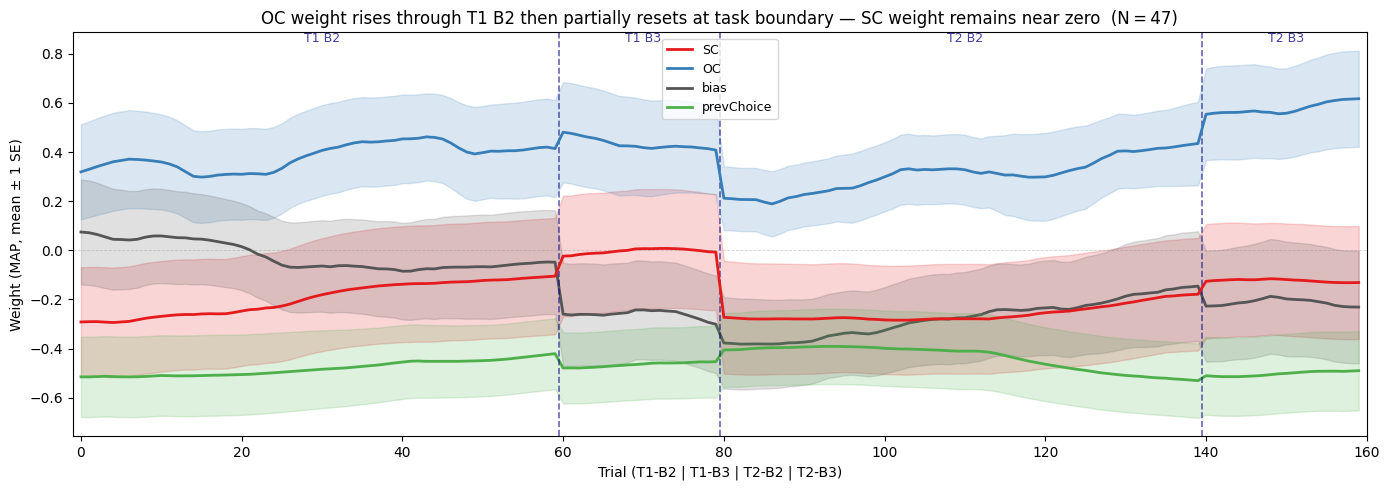

In [22]:
good_fits = {sid: fit for sid, fit in v2_fits.items() if sid not in flagged_ids}
wns = weight_names(next(iter(good_fits.values()))["weights"])  # sorted: [OC, SC, bias, prevChoice]
t = np.arange(160)

fig, ax = plt.subplots(figsize=(14, 5))

for wname in ["SC", "OC", "bias", "prevChoice"]:
    idx = wns.index(wname)
    trajs = np.vstack([fit["wMode"][idx] for fit in good_fits.values()])
    mean_w = trajs.mean(axis=0)
    se_w   = trajs.std(axis=0) / np.sqrt(len(good_fits))
    ax.fill_between(t, mean_w - se_w, mean_w + se_w, color=WEIGHT_COLORS[wname], alpha=0.18)
    ax.plot(t, mean_w, color=WEIGHT_COLORS[wname], lw=2.0, label=wname,
            zorder=WEIGHT_ZORDER.get(wname, 3))

for xv in [60, 80, 140]:
    ax.axvline(xv - 0.5, color="navy", lw=1.2, ls="--", alpha=0.6)
ax.axhline(0, color="grey", lw=0.6, ls="--", alpha=0.35)

for x0, x1, label in [(0, 60, "T1 B2"), (60, 80, "T1 B3"), (80, 140, "T2 B2"), (140, 160, "T2 B3")]:
    ax.annotate(label, xy=((x0 + x1) / 2, 1.0), xycoords=("data", "axes fraction"),
                ha="center", va="top", fontsize=9, color="navy", alpha=0.75)

ax.set_xlabel("Trial (T1-B2 | T1-B3 | T2-B2 | T2-B3)")
ax.set_ylabel("Weight (MAP, mean \u00b1 1 SE)")
ax.set_title(
    f"OC weight rises through T1 B2 then partially resets at task boundary — "
    f"SC weight remains near zero  (N\u202f=\u202f{len(good_fits)})"
)
ax.legend(fontsize=9)
ax.set_xlim(-1, 160)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "psytrack_aggregate_concatenated.png", dpi=150)
plt.show()

## Aggregate weight trajectory findings

The `OC` weight rises through T1 B2, reaching a mean of ~0.3 – 0.4 logits, then drops by roughly 0.25 at the task boundary. It then rebuilds through T2 B2.      
The drop reflects a partial reset of the OC association, which is consistent with the experimental design: the OC property assignment changes at the task boundary (OC and R swap roles), so the physical stimulus associated with high outcome probability changes. Subjects seem to partially retain sensitivity from T1.

The `SC` weight remains near zero throughout both tasks. It does not show the positive learning trajectory seen in OC, and there is no visible acceleration in T2 that would indicate transfer of an SC association. The transfer index for SC (mean = −0.17, 95% CI [−0.50, 0.17]) is consistent with zero. Rather than failing to prove transfer of learning, it suggests that contingency does not clearly build in the first place : transfer is not robustly testable at that weight level.

The asymmetry between a clear `OC` trajectory and a weak `SC` trajectory is consistent with the preregistered falsification target (drawn from *Palminteri, Wyart & Koechlin, 2017*): subjects appear to track environmental causal structure (a property predicting outcomes) more readily than action-conditional contingency (the effect of pressing, given this property, on outcome probability). 
  
This pattern aligns with the behavioural results in notebook 03, where H1 (SC > R press rate) and H2 (positive transfer index) are both weak or null.

SC_transfer (N=47):  mean = -0.167,  95% CI [-0.504, 0.170]


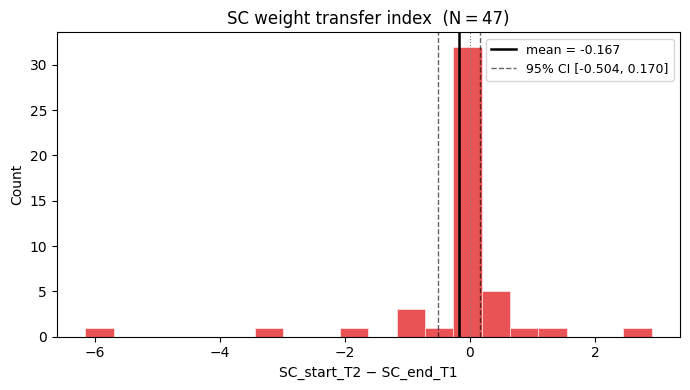

In [ ]:
TRANSFER_PATH = Path("../data/processed/psytrack_weight_transfer.csv")
wns_t = weight_names(next(iter(v2_fits.values()))["weights"])

rows = []
for subject_id, fit in v2_fits.items():
    wMode = fit["wMode"]
    row = {"subject_id": subject_id}
    for wname in ["SC", "OC", "prevChoice"]:
        idx = wns_t.index(wname)
        w = wMode[idx]
        end_t1   = float(w[55:60].mean())   # last 5 trials of T1-B2
        start_t2 = float(w[80:85].mean())   # first 5 trials of T2-B2
        row[f"{wname}_end_T1"]   = end_t1
        row[f"{wname}_start_T2"] = start_t2
        row[f"{wname}_transfer"] = start_t2 - end_t1
    rows.append(row)

transfer_df = pd.DataFrame(rows)
transfer_df.to_csv(TRANSFER_PATH, index=False)


# SC transfer summary across non-flagged subjects

sc_tr = transfer_df.loc[~transfer_df["subject_id"].isin(flagged_ids), "SC_transfer"]
ci95 = 1.96 * sc_tr.std() / np.sqrt(len(sc_tr))
print(f"SC_transfer (N={len(sc_tr)}):  mean = {sc_tr.mean():.3f},  95% CI [{sc_tr.mean() - ci95:.3f}, {sc_tr.mean() + ci95:.3f}]")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sc_tr, bins=20, color=WEIGHT_COLORS["SC"], alpha=0.75, edgecolor="white", linewidth=0.5)
ax.axvline(sc_tr.mean(), color="black", lw=1.8, ls="-",
           label=f"mean = {sc_tr.mean():.3f}")
ax.axvline(sc_tr.mean() - ci95, color="black", lw=1.0, ls="--", alpha=0.6)
ax.axvline(sc_tr.mean() + ci95, color="black", lw=1.0, ls="--", alpha=0.6,
           label=f"95% CI [{sc_tr.mean() - ci95:.3f}, {sc_tr.mean() + ci95:.3f}]")
ax.axvline(0, color="grey", lw=0.8, ls=":")
ax.set_xlabel("SC_start_T2 \u2212 SC_end_T1")
ax.set_ylabel("Count")
ax.set_title(f"SC weight transfer index  (N\u202f=\u202f{len(sc_tr)})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "psytrack_sc_transfer_histogram.png", dpi=150)
plt.show()

## Methods

The application shows that PsyTrack is feasible on short behavioural sessions and produces qualitative trajectories consistent with the behavioural analyses - however, the method is not well-matched to the dataset or experimental design. 
- The OC weight trajectory is informative and interpretable. 
- The SC weight trajectory is too noisy at the single-subject level to support reliable per-subject transfer estimates. 
- 31% of subjects produce pathological fits regardless of fitting configuration, which reflects the fundamental mismatch in trial counts: PsyTrack’s empirical Bayes optimisation becomes underdetermined when there is insufficient data to constrain four time-varying weights plus their smoothness hyperparameters.    

A longer experimental design — hundreds of trials per task, or across-session concatenation in a longitudinal paradigm — would put the method in the regime for which it was designed. The qualitative finding (OC weight builds, SC weight does not) stands and provides a result to the hypothesis driving the experiment. Quantitative weight-level claims about transfer are treated cautiously in the discussion.

## Connection to the Review's Hypothesis

This experiment suggests a minimal follow-up test : can agents acquire action-conditional contingency when competing environment-driven causality is present, and more easily extracted? Contingency was operationalised as the self-indexed output of causal inference in the companion review - it would suggest that learning, and self-related priors encode patterns of self-caused contingency (hypothesised to be indexed to the properties they co-occur with). 

The preliminary evidence here suggests OC structure is acquired more readily than SC contingency, and SC weight does not clearly build across either task. Two follow-up questions emerge from this analysis. First, what experimental designs could best isolate contingency learning from causal-structure learning? Second, what methods are best suited to detecting fine-grained belief dynamics in regimes with short per-session trial counts?